In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

df = pd.read_excel('../../jhani_pandit_dataset/Fitness_Survey__Responses_clean.xlsx')

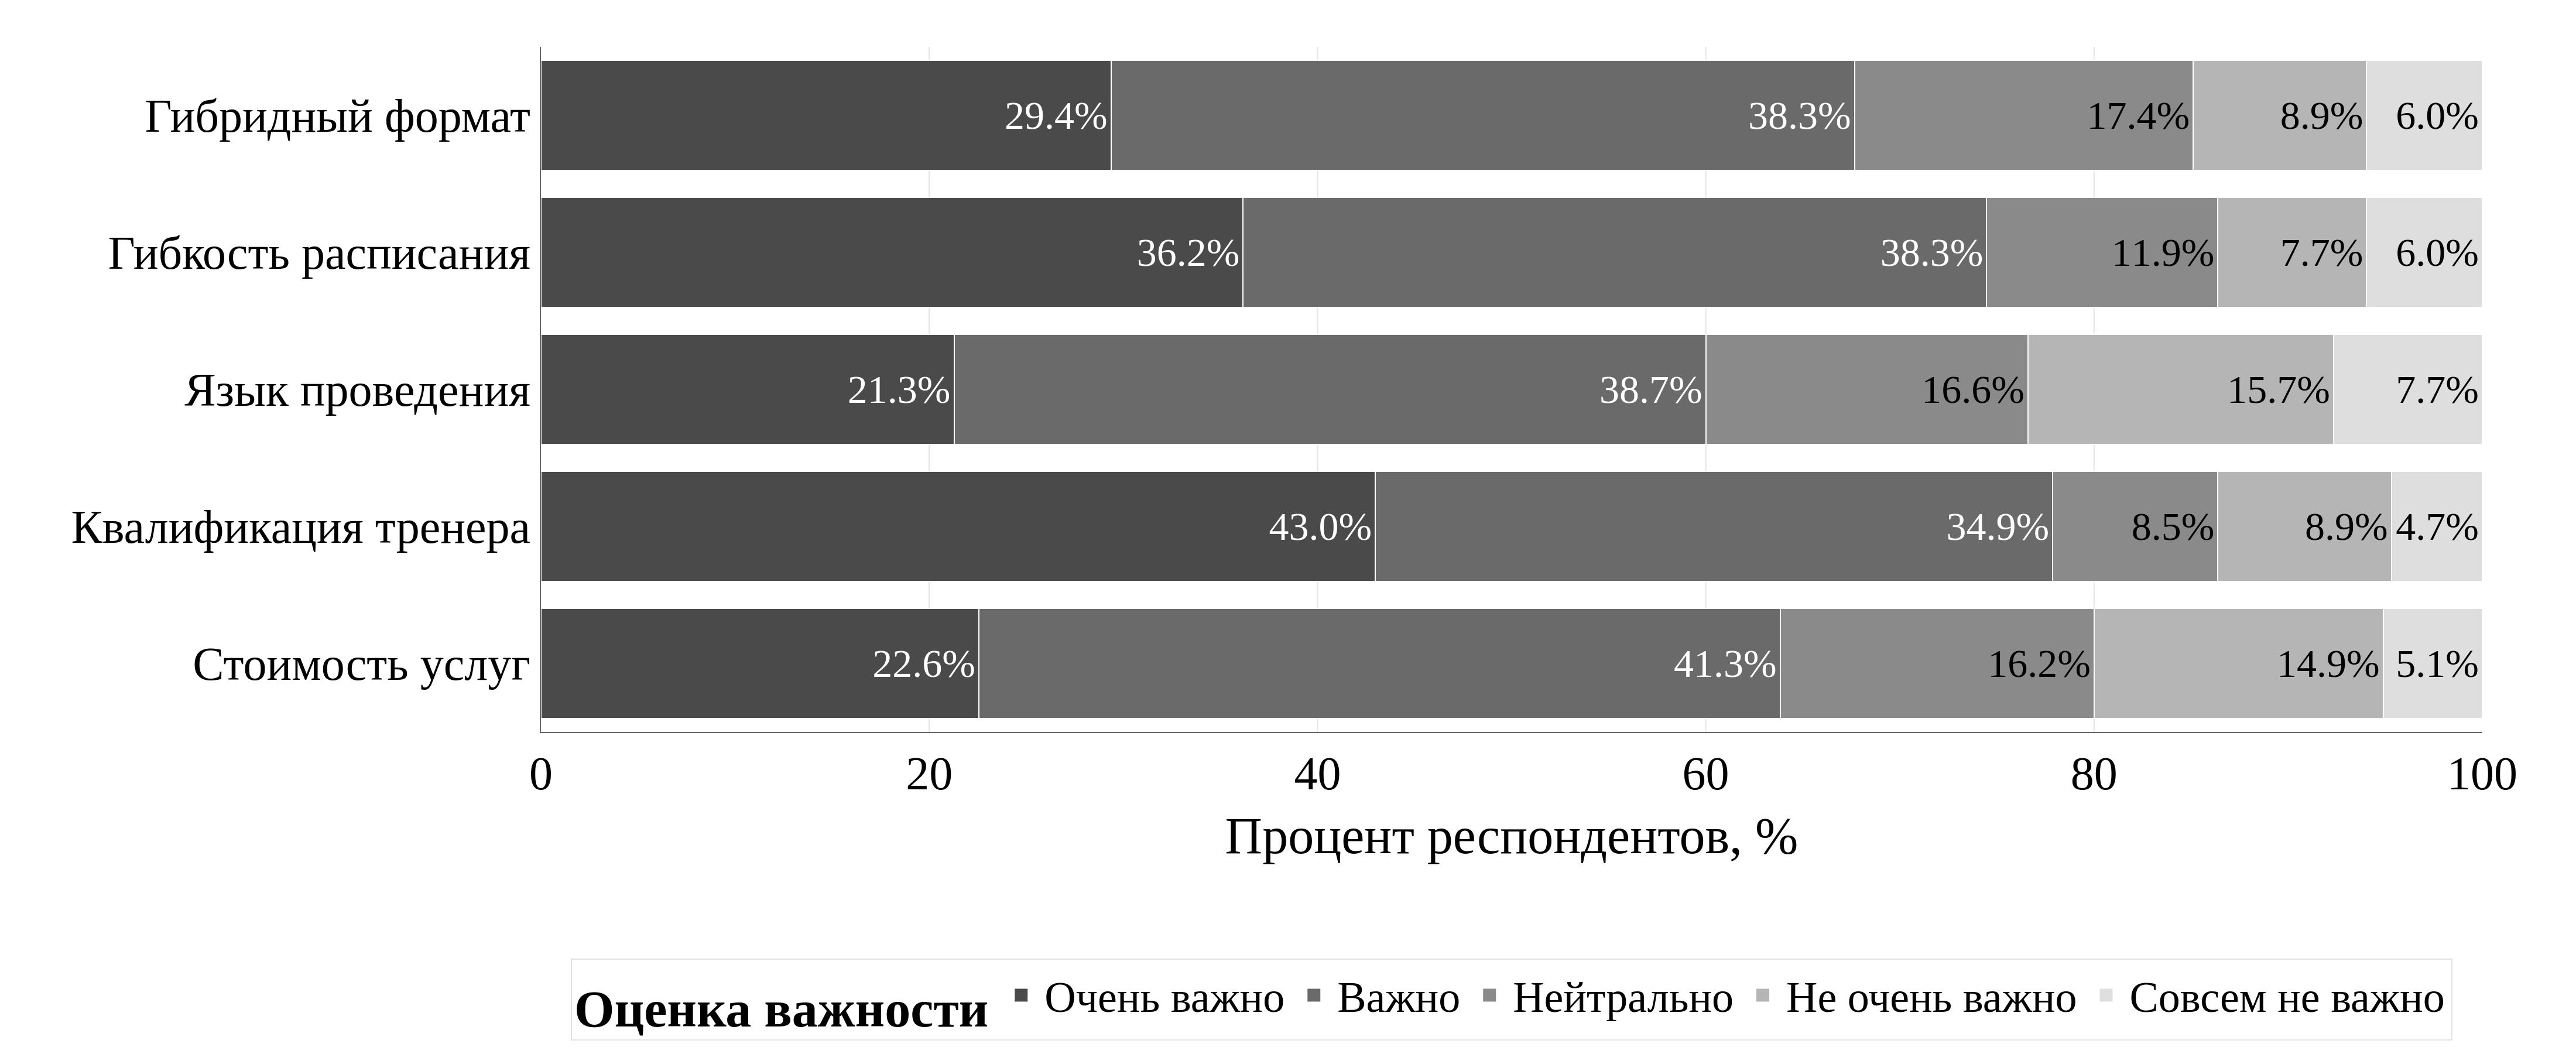

In [2]:
criteria_cols = {
    "Please rate your preferences for each of the following criteria while choosing a wellness/fitness service provider [Price of service]": "Стоимость услуг",
    "Please rate your preferences for each of the following criteria while choosing a wellness/fitness service provider [Expertise credibility of the trainer(s)]": "Квалификация тренера",
    "Please rate your preferences for each of the following criteria while choosing a wellness/fitness service provider [Language of training/practice instructions in your regional language as compared to English?]": "Язык проведения",
    "Please rate your preferences for each of the following criteria while choosing a wellness/fitness service provider [Flexibility of choosing different time slots for training/practice on different days]": "Гибкость расписания",
    "Please rate your preferences for each of the following criteria while choosing a wellness/fitness service provider [Availability of hybrid options for training/practice (ability to choose online and offline training session as per my convenience)]": "Гибридный формат"
}

rating_order = ["Very Important", "Important", "Neutral", "Not so important", "Not important at all"]
rating_ru = {
    "Very Important": "Очень важно",
    "Important": "Важно",
    "Neutral": "Нейтрально",
    "Not so important": "Не очень важно",
    "Not important at all": "Совсем не важно"
}

colors_likert = ['#4A4A4A', '#6A6A6A', '#8A8A8A', '#B5B5B5', '#DEDEDE']
text_colors = ['white', 'white', 'black', 'black', 'black']

data_for_plot = []
for col_eng, col_ru in criteria_cols.items():
    counts = df[col_eng].value_counts()
    total = counts.sum()
    percentages = [(counts.get(rating, 0) / total * 100) for rating in rating_order]
    data_for_plot.append({
        'criterion': col_ru,
        'percentages': percentages
    })

fig = go.Figure()

for i, rating in enumerate(rating_order):
    values = [item['percentages'][i] for item in data_for_plot]
    labels = [item['criterion'] for item in data_for_plot]
    
    text_labels = [f'{v:.1f}%' if v >= 0 else '' for v in values]
    
    fig.add_trace(go.Bar(
        name=rating_ru[rating],
        y=labels,
        x=values,
        orientation='h',
        marker=dict(color=colors_likert[i], line=dict(color='white', width=1)),
        text=text_labels,
        textposition='inside',
        textfont=dict(size=34, color=text_colors[i], family='Times New Roman'),
        hovertemplate='<b>%{y}</b><br>' + rating_ru[rating] + ': %{x:.1f}%<extra></extra>'
    ))

n_respondents = int(df[list(criteria_cols.keys())[0]].notna().sum())

fig.update_layout(
    barmode="stack",
    showlegend=True,

    paper_bgcolor="white",
    plot_bgcolor="white",

    font=dict(
        family="Times New Roman",
        size=40,
        color="#000000"
    ),

    xaxis=dict(
        title="Процент респондентов, %",
        titlefont=dict(size=44),
        tickfont=dict(size=40),
        showgrid=True,
        gridcolor=GRID_COLOR,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, 100]
    ),

    yaxis=dict(
        title="",
        tickfont=dict(size=40),
        showgrid=False,
        linecolor=AXIS_COLOR,
        linewidth=1
    ),

    legend=dict(
        title="<b>Оценка важности</b>",
        orientation="h",
        yanchor="bottom",
        y=-0.45,
        xanchor="center",
        x=0.5,
        font=dict(size=37),
        traceorder="normal",
        bgcolor="rgba(255,255,255,0.95)",
        bordercolor=GRID_COLOR,
        borderwidth=1
    ),

    margin=dict(
        l=320,
        r=80,
        t=40,
        b=220
    ),

    width=2200,
    height=900
)

fig.show()